In [8]:
import os
import shutil
import numpy as np
import glob
from obspy import read, read_inventory
from obspy.geodetics import gps2dist_azimuth, kilometers2degrees

# --- 1. 路径与核心参数设置 ---
input_dir = './RAWXML'  # 确认这是你存放 .mseed 和 .sxml 的目录       
select_dir = './PSELECTXML'
average_dir = './DISTSELECTXML'        # 震中距均衡后的输出目
# 汶川大地震位置
ev_lat = 31.021
ev_lon = 103.367

snr_threshold = 5.0   # SNR 筛选阈值
noise_window = 10.0   # P波到达前 10 秒
signal_window = 5.0   # P波到达后 5 秒

for d in [select_dir, average_dir]:
    if not os.path.exists(d):
        os.makedirs(d)

# --- 2. SNR 计算函数 ---
def calculate_snr(tr, p_arrival):
    try:
        df = tr.stats.sampling_rate
        # p_arrival 是相对于 starttime 的秒数
        n_start = int((p_arrival - noise_window) * df)
        n_end = int(p_arrival * df)
        s_start = n_end
        s_end = int((p_arrival + signal_window) * df)
        
        noise = tr.data[n_start:n_end]
        signal = tr.data[s_start:s_end]
        
        if len(noise) < 10 or len(signal) < 10: return 0
        rms_noise = np.sqrt(np.mean(noise**2))
        rms_signal = np.sqrt(np.mean(signal**2))
        
        return rms_signal / rms_noise if rms_noise > 0 else 0
    except Exception:
        return 0

# --- 3. 扫描目录并按台站分组 ---
# 搜索所有的 Z 分量 mseed 文件
z_mseed_files = glob.glob(os.path.join(input_dir, '*BHZ*.mseed'))
station_groups = {}

print(f"开始扫描 {input_dir}...")

for z_file in z_mseed_files:
    basename = os.path.basename(z_file)
    parts = basename.split('.')
    net, sta, loc = parts[0], parts[1], parts[2]
    group_key = f"{net}.{sta}.{loc}"
    
    # 构造该台站该位置的所有相关文件前缀
    base_pattern = os.path.join(input_dir, f"{net}.{sta}.{loc}")
    
    try:
        # 【核心修改】：从配套的 .sxml 中读取经纬度
        sxml_path = glob.glob(f"{base_pattern}.BHZ*.sxml")[0]
        inv = read_inventory(sxml_path)
        sta_lat = inv[0][0].latitude
        sta_lon = inv[0][0].longitude
        
        # 计算震中距 (度)
        dist_m, az, baz = gps2dist_azimuth(ev_lat, ev_lon, sta_lat, sta_lon)
        dist_deg = kilometers2degrees(dist_m / 1000.0) 
        
        # 读取 Z 分量计算 SNR (假设 P 波在 300s)
        tr = read(z_file)[0]
        tr.filter('bandpass', freqmin=0.5, freqmax=2.0)
        snr = calculate_snr(tr, 300.0)
        
        # 收集该 Loc 下的所有文件 (BHE/N/Z 的 mseed 和 sxml)
        all_related = glob.glob(f"{base_pattern}*")
        
        station_groups[group_key] = {
            'files': all_related,
            'snr': snr,
            'dist': dist_deg,
            'sta_name': sta,
            'loc': loc
        }
    except Exception as e:
        print(f"跳过台站 {sta}.{loc}: {e}")
        continue

# --- 4. 震中距均衡筛选 (30-90度) ---
# 将合格的台站放入 6 个箱子 (30-40, 40-50, ..., 80-90)
bins = [[] for _ in range(6)]
for gid, info in station_groups.items():
    if info['snr'] >= snr_threshold and 30 <= info['dist'] <= 90:
        # 复制到初步筛选目录
        for f in info['files']:
            shutil.copy(f, os.path.join(select_dir, os.path.basename(f)))
            
        bin_idx = int((info['dist'] - 30) // 10)
        if bin_idx > 5: bin_idx = 5
        bins[bin_idx].append(info)

print(f"\nSNR 筛选完成。开始每 10 度区间保留前 3 个最优台站...")

final_count = 0
for i, bin_groups in enumerate(bins):
    d_start, d_end = 30 + i*10, 40 + i*10
    if not bin_groups:
        print(f"区间 [{d_start}-{d_end}°]: 无合格数据")
        continue
    
    # 按 SNR 排序取前 3
    best_3 = sorted(bin_groups, key=lambda x: x['snr'], reverse=True)[:3]
    print(f"区间 [{d_start}-{d_end}°]: 找到 {len(bin_groups)} 个，保留 {len(best_3)} 个")
    
    for rank, group in enumerate(best_3, 1):
        print(f"  Top {rank}: {group['sta_name']}({group['loc']}) dist={group['dist']:.2f}°, SNR={group['snr']:.2f}")
        for f in group['files']:
            shutil.copy(f, os.path.join(average_dir, os.path.basename(f)))
        final_count += 1

print(f"\n处理完成！最终在 {average_dir} 中保留了 {final_count} 个均衡分布的台站。")

开始扫描 ./RAWXML...


/var/folders/s_/c0gkp6m16fggk4b8r3b5yhym0000gp/T/ipykernel_2198/2358541836.py:69: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  dist_m, az, baz = gps2dist_azimuth(ev_lat, ev_lon, sta_lat, sta_lon)
/var/folders/s_/c0gkp6m16fggk4b8r3b5yhym0000gp/T/ipykernel_2198/2358541836.py:69: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  dist_m, az, baz = gps2dist_azimuth(ev_lat, ev_lon, sta_lat, sta_lon)
/var/folders/s_/c0gkp6m16fggk4b8r3b5yhym0000gp/T/ipykernel_2198/2358541836.py:69: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  dist_m, az, baz = gps2dist_azimuth(ev_lat, ev_lon, sta_lat, sta_lon)
/var/folders/s_/c0gkp6m16fggk4b8r3b5yhym0000gp/T/ipykernel_2198/2358541836.py:69: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in 


SNR 筛选完成。开始每 10 度区间保留前 3 个最优台站...
区间 [30-40°]: 找到 8 个，保留 3 个
  Top 1: BRVK(00) dist=32.52°, SNR=81.92
  Top 2: YSS(00) dist=34.09°, SNR=57.00
  Top 3: PALK(10) dist=31.77°, SNR=26.84
区间 [40-50°]: 找到 10 个，保留 3 个
  Top 1: ARU(00) dist=40.09°, SNR=103.97
  Top 2: KIV(10) dist=48.82°, SNR=36.20
  Top 3: KIV(00) dist=48.82°, SNR=34.51
区间 [50-60°]: 找到 15 个，保留 3 个
  Top 1: OBN(00) dist=52.09°, SNR=47.63
  Top 2: OBN(10) dist=52.09°, SNR=45.48
  Top 3: WRAB(00) dist=58.81°, SNR=32.20
区间 [60-70°]: 找到 11 个，保留 3 个
  Top 1: ALE(10) dist=66.39°, SNR=54.81
  Top 2: ALE(00) dist=66.39°, SNR=54.07
  Top 3: GRFO() dist=68.30°, SNR=47.80
区间 [70-80°]: 找到 11 个，保留 3 个
  Top 1: BFO(00) dist=70.59°, SNR=43.65
  Top 2: ESK(00) dist=73.62°, SNR=30.20
  Top 3: KDAK(00) dist=71.18°, SNR=19.89
区间 [80-90°]: 找到 10 个，保留 3 个
  Top 1: PAB(00) dist=82.88°, SNR=32.14
  Top 2: SFJD(00) dist=80.19°, SNR=18.00
  Top 3: SFJD(10) dist=80.19°, SNR=17.55

处理完成！最终在 ./DISTSELECTXML 中保留了 18 个均衡分布的台站。


In [9]:
import glob
import os
import obspy
from obspy import read, read_inventory
from obspy.geodetics import gps2dist_azimuth

# ==========================================
# 1. 设置输入和输出文件夹
# ==========================================
input_dir = "DISTSELECTXML" 
output_dir = "RESPONCE"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

evla = 31.021
evlo = 103.367

# ==========================================
# 2. 自动筛选完整台站及最优 Location
# ==========================================
selected_stations = {}

z_files = sorted(glob.glob(os.path.join(input_dir, '*BHZ*.mseed')))

for z_file in z_files:
    basename = os.path.basename(z_file)
    parts = basename.split('.')
    net, sta, loc = parts[0], parts[1], parts[2]
    sta_key = f"{net}.{sta}"
    
    if sta_key in selected_stations:
        continue
        
    base_pattern = os.path.join(input_dir, f"{net}.{sta}.{loc}")
    
    has_e = len(glob.glob(f"{base_pattern}.BHE*.mseed")) > 0
    has_n = len(glob.glob(f"{base_pattern}.BHN*.mseed")) > 0
    has_z = len(glob.glob(f"{base_pattern}.BHZ*.mseed")) > 0
    
    has_sxml_e = len(glob.glob(f"{base_pattern}.BHE*.sxml")) > 0
    has_sxml_n = len(glob.glob(f"{base_pattern}.BHN*.sxml")) > 0
    has_sxml_z = len(glob.glob(f"{base_pattern}.BHZ*.sxml")) > 0
    
    if has_e and has_n and has_z and has_sxml_e and has_sxml_n and has_sxml_z:
        selected_stations[sta_key] = loc

print(f"✅ 自动扫描完成！共挑选出 {len(selected_stations)} 个拥有完整数据的台站准备处理。\n" + "-"*40)

# ==========================================
# 3. 正式处理筛选好的台站
# ==========================================
for sta_key, loc in selected_stations.items():
    net, sta = sta_key.split('.')
    base_pattern = os.path.join(input_dir, f"{net}.{sta}.{loc}")
    
    try:
        # 读取波形
        st_e = read(glob.glob(f"{base_pattern}.BHE*.mseed")[0])
        st_n = read(glob.glob(f"{base_pattern}.BHN*.mseed")[0])
        st_z = read(glob.glob(f"{base_pattern}.BHZ*.mseed")[0])
        st1 = st_e + st_n + st_z
        
        # 分别读取三个方向的 sxml 文件
        inv_e = read_inventory(glob.glob(f"{base_pattern}.BHE*.sxml")[0])
        inv_n = read_inventory(glob.glob(f"{base_pattern}.BHN*.sxml")[0])
        inv_z = read_inventory(glob.glob(f"{base_pattern}.BHZ*.sxml")[0])
        
        # 合并为一个完整的 inventory
        inv1 = inv_e + inv_n + inv_z
        
        # 提取台站坐标
        stla = inv1[0][0].latitude
        stlo = inv1[0][0].longitude
        
        # 去除仪器响应
        st1.attach_response(inv1)
        st1.detrend('linear')
        st1.detrend('constant')
        st1.merge(1, 0)
        st1.remove_response(output='VEL', pre_filt=(1.0/180, 1.0/150, 4, 5))
        
        # 旋转
        dist, az, baz = gps2dist_azimuth(evla, evlo, stla, stlo)
        st1.rotate(method="NE->RT", inventory=inv1, back_azimuth=baz)
        
        # 保存
        for tr in st1:
            if not hasattr(tr.stats, 'sac'):
                tr.stats.sac = obspy.core.AttribDict()
            
            tr.stats.sac.stla = stla
            tr.stats.sac.stlo = stlo
            tr.stats.sac.evla = evla
            tr.stats.sac.evlo = evlo
            tr.stats.sac.dist = dist / 1000.0  
            
            channel = tr.stats.channel
            out_filename = f"{net}.{sta}.{loc}.{channel}.sac"
            out_filepath = os.path.join(output_dir, out_filename)
            
            tr.write(out_filepath, format="SAC")
            
        print(f"处理成功: 台站 {sta} (选用的 Location: {loc})")

    except Exception as e:
        print(f"❌ 错误: 台站 {sta} 处理失败，原因: {e}")

✅ 自动扫描完成！共挑选出 13 个拥有完整数据的台站准备处理。
----------------------------------------


/var/folders/s_/c0gkp6m16fggk4b8r3b5yhym0000gp/T/ipykernel_2198/1337754286.py:84: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  dist, az, baz = gps2dist_azimuth(evla, evlo, stla, stlo)
/var/folders/s_/c0gkp6m16fggk4b8r3b5yhym0000gp/T/ipykernel_2198/1337754286.py:84: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  dist, az, baz = gps2dist_azimuth(evla, evlo, stla, stlo)


处理成功: 台站 ALE (选用的 Location: 00)
处理成功: 台站 ARU (选用的 Location: 00)


/var/folders/s_/c0gkp6m16fggk4b8r3b5yhym0000gp/T/ipykernel_2198/1337754286.py:84: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  dist, az, baz = gps2dist_azimuth(evla, evlo, stla, stlo)
/var/folders/s_/c0gkp6m16fggk4b8r3b5yhym0000gp/T/ipykernel_2198/1337754286.py:84: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  dist, az, baz = gps2dist_azimuth(evla, evlo, stla, stlo)


处理成功: 台站 BFO (选用的 Location: 00)
处理成功: 台站 BRVK (选用的 Location: 00)


...

/var/folders/s_/c0gkp6m16fggk4b8r3b5yhym0000gp/T/ipykernel_2198/1337754286.py:84: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  dist, az, baz = gps2dist_azimuth(evla, evlo, stla, stlo)
/var/folders/s_/c0gkp6m16fggk4b8r3b5yhym0000gp/T/ipykernel_2198/1337754286.py:84: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  dist, az, baz = gps2dist_azimuth(evla, evlo, stla, stlo)


处理成功: 台站 OBN (选用的 Location: 00)
处理成功: 台站 WRAB (选用的 Location: 00)


/var/folders/s_/c0gkp6m16fggk4b8r3b5yhym0000gp/T/ipykernel_2198/1337754286.py:84: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  dist, az, baz = gps2dist_azimuth(evla, evlo, stla, stlo)
/var/folders/s_/c0gkp6m16fggk4b8r3b5yhym0000gp/T/ipykernel_2198/1337754286.py:84: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  dist, az, baz = gps2dist_azimuth(evla, evlo, stla, stlo)


处理成功: 台站 GRFO (选用的 Location: )
处理成功: 台站 PAB (选用的 Location: 00)
处理成功: 台站 SFJD (选用的 Location: 00)
处理成功: 台站 YSS (选用的 Location: 00)


/var/folders/s_/c0gkp6m16fggk4b8r3b5yhym0000gp/T/ipykernel_2198/1337754286.py:84: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  dist, az, baz = gps2dist_azimuth(evla, evlo, stla, stlo)
/var/folders/s_/c0gkp6m16fggk4b8r3b5yhym0000gp/T/ipykernel_2198/1337754286.py:84: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  dist, az, baz = gps2dist_azimuth(evla, evlo, stla, stlo)


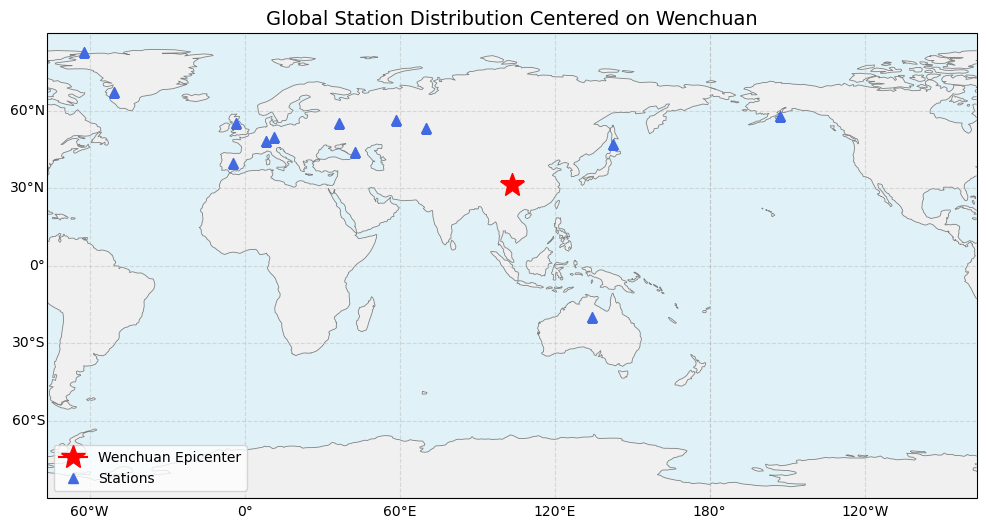

✅ 第 1 张图：台站分布图已保存 (Figure_1_Map.png)
✅ 第 2 张图：Z 分量剖面图已保存 (Figure_2_Profile_Z.png)
✅ 第 3 张图：R 分量剖面图已保存 (Figure_3_Profile_R.png)
✅ 第 4 张图：T 分量剖面图已保存 (Figure_4_Profile_T.png)


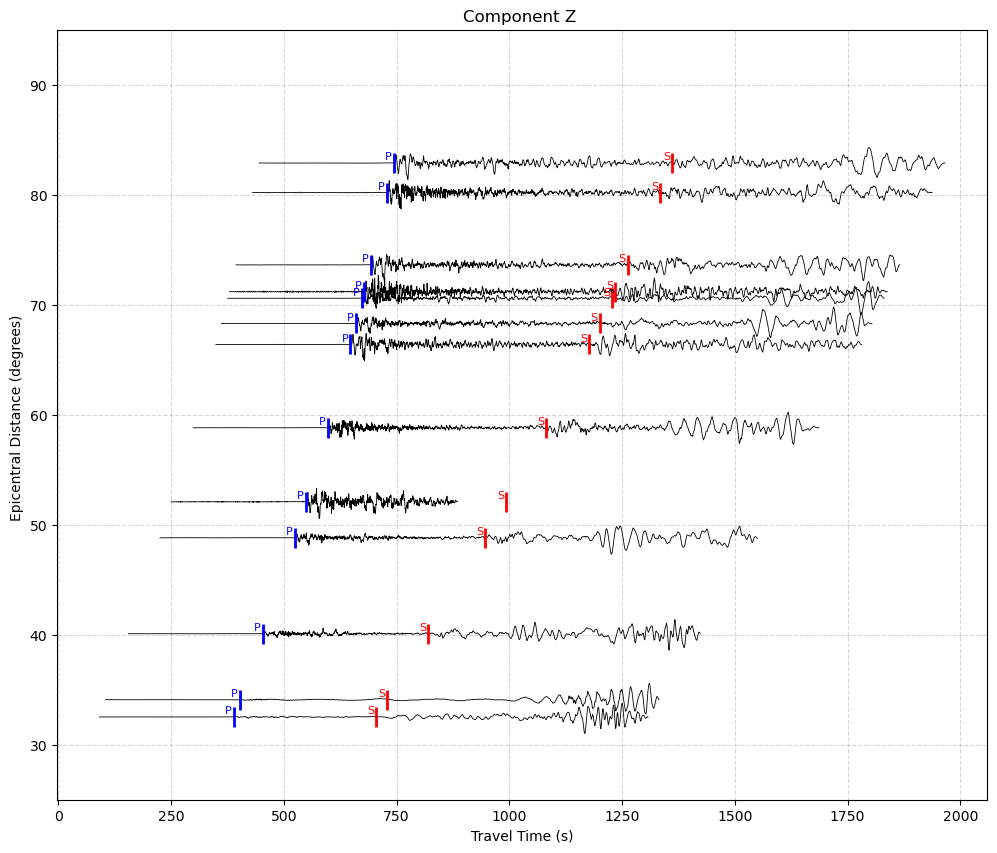

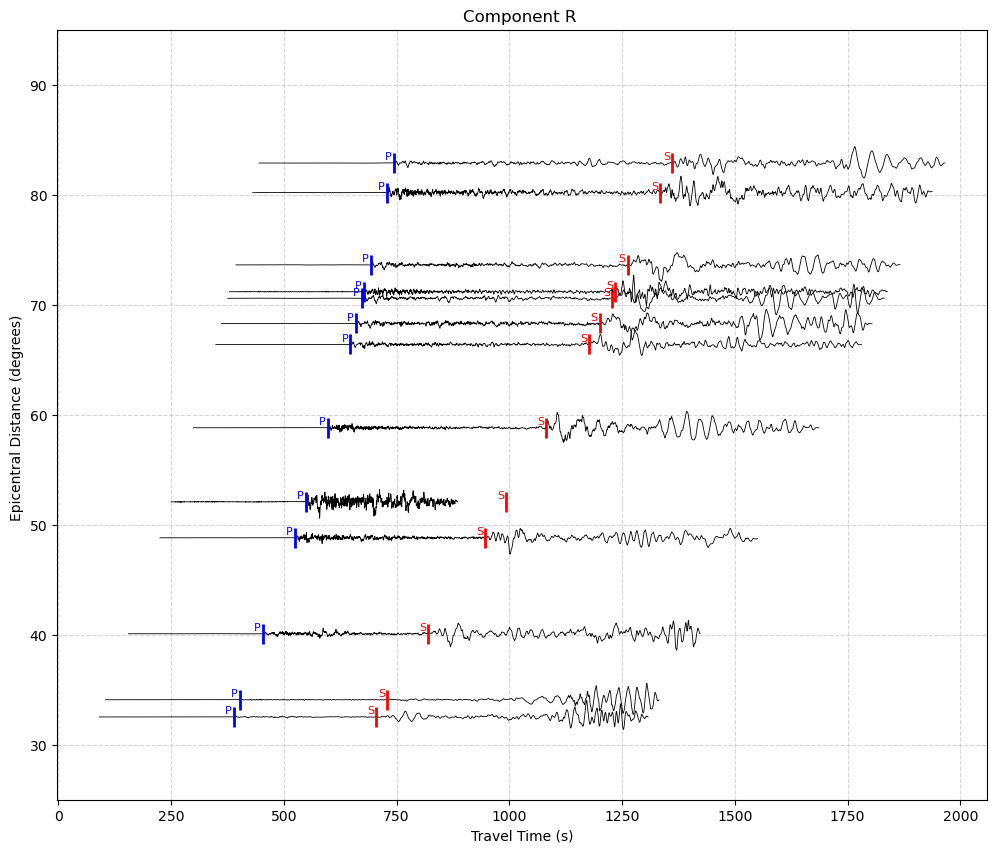

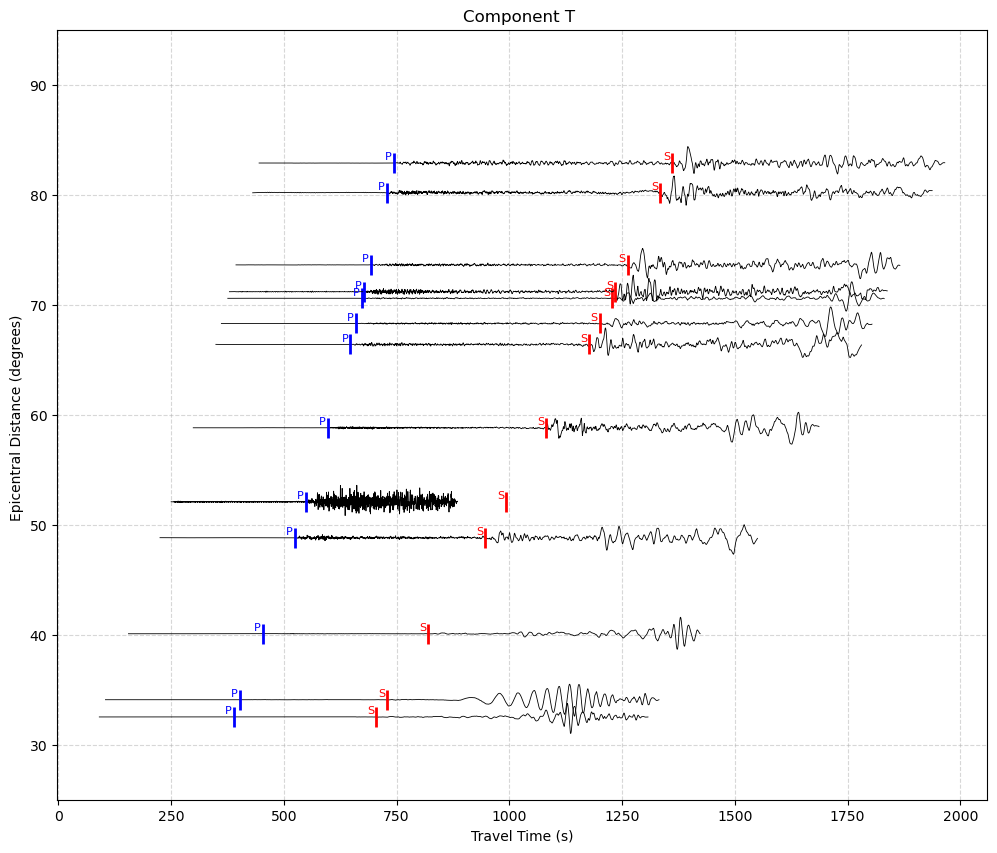

In [11]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from obspy import read, UTCDateTime
from obspy.taup import TauPyModel
from obspy.geodetics import kilometers2degrees

# ==========================================
# 0. 基本参数设置
# ==========================================
data_dir = "RESPONCE"
# 汶川大地震发震时刻和深度 (用于计算走时)
event_time = UTCDateTime("2008-05-12T06:28:01")
evla, evlo = 31.021, 103.367
evdp = 19.0  # 震源深度约 19 km

# 初始化 TauP 模型 (1D 走时计算 [cite: 8])
model = TauPyModel(model="iasp91")

# 读取所有处理好的 SAC 数据
st = read(os.path.join(data_dir, "*.sac"))

# 提取台站坐标和震中距用于画地图
sta_lats = []
sta_lons = []
for tr in st.select(component="Z"): # 仅用Z分量提取一次台站即可
    sta_lats.append(tr.stats.sac.stla)
    sta_lons.append(tr.stats.sac.stlo)

# --- 设定中心经度为汶川经度 ---
wenchuan_lon = 103.367
wenchuan_lat = 31.021

fig_map = plt.figure(figsize=(12, 8))

# 【核心修改】创建投影时指定 central_longitude
# 这会使地图的“横向中心”落在汶川
ax_map = plt.axes(projection=ccrs.PlateCarree(central_longitude=wenchuan_lon))

# 依然使用全局范围，但视觉中心已改变
ax_map.set_global() 

# 添加地理特征 
ax_map.add_feature(cfeature.LAND, facecolor='#f0f0f0')
ax_map.add_feature(cfeature.OCEAN, facecolor='#e0f2f7')
ax_map.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor='gray')

# 画震源 (红色五角星) 
# 注意：即使投影设置了中心经度，plot 时的 transform 仍用标准的 PlateCarree()
ax_map.plot(wenchuan_lon, wenchuan_lat, marker='*', color='red', markersize=18, 
            transform=ccrs.PlateCarree(), label='Wenchuan Epicenter', zorder=5)

# 画台站 (蓝色三角形) 
ax_map.plot(sta_lons, sta_lats, marker='^', color='royalblue', markersize=7, 
            linestyle='', transform=ccrs.PlateCarree(), label='Stations', zorder=4)

# 添加经纬度网格
gl = ax_map.gridlines(draw_labels=True, linestyle='--', alpha=0.4)
gl.top_labels = False
gl.right_labels = False

plt.title("Global Station Distribution Centered on Wenchuan", fontsize=14)
plt.legend(loc='lower left')

plt.savefig("Figure_1_Wenchuan_Centered.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ 第 1 张图：台站分布图已保存 (Figure_1_Map.png)")

# ==========================================
# 2. 绘制 Z, R, T 三分量地震图剖面 (第 2, 3, 4 张图) [cite: 2]
# ==========================================
components = ['Z', 'R', 'T']
# 振幅缩放因子，避免波形互相重叠 (可根据实际出图效果微调该数值)
scale_factor = 1.5 

for comp in components:
    fig, ax = plt.subplots(figsize=(12, 10))
    st_comp = st.select(component=comp)
    
    for tr in st_comp:
        # 获取距离 (将 km 转换为度 [cite: 2])
        dist_km = tr.stats.sac.dist
        dist_deg = kilometers2degrees(dist_km)
        
        # 计算每个数据点的相对走时 (X轴) [cite: 2]
        # X = 当前点的绝对时间 - 发震时刻
        times = tr.times() + (tr.stats.starttime - event_time)
        
        # 归一化振幅
        norm_data = tr.data / np.max(np.abs(tr.data))
        # 将波形平移到对应的震中距 (Y轴) [cite: 2]
        plot_data = norm_data * scale_factor + dist_deg
        
        # 画波形
        ax.plot(times, plot_data, color='black', linewidth=0.6)
        
        # 计算理论到时 [cite: 8]
        try:
            # P波 (P或Pdiff)
            arrivals_p = model.get_travel_times(source_depth_in_km=evdp, distance_in_degree=dist_deg, phase_list=["P", "Pdiff"])
            if arrivals_p:
                p_time = arrivals_p[0].time
                # 在地震波上标记理论到时 [cite: 2]
                ax.plot(p_time, dist_deg, marker='|', color='blue', markersize=15, markeredgewidth=2)
                ax.text(p_time - 20, dist_deg + 0.3, 'P', color='blue', fontsize=8)
                
            # S波 (S或Sdiff)
            arrivals_s = model.get_travel_times(source_depth_in_km=evdp, distance_in_degree=dist_deg, phase_list=["S", "Sdiff"])
            if arrivals_s:
                s_time = arrivals_s[0].time
                ax.plot(s_time, dist_deg, marker='|', color='red', markersize=15, markeredgewidth=2)
                ax.text(s_time - 20, dist_deg + 0.3, 'S', color='red', fontsize=8)
        except Exception as e:
            pass # 某些极端的震中距可能算不出基础震相，直接跳过

    ax.set_xlabel("Travel Time (s)")
    ax.set_ylabel("Epicentral Distance (degrees) ")
    ax.set_title(f"Component {comp} ")
    ax.set_ylim(25, 95) # 作业要求30-90度，适当放宽显示范围 [cite: 2]
    ax.grid(True, linestyle='--', alpha=0.5)
    
    out_name = f"Figure_{components.index(comp)+2}_Profile_{comp}.png"
    plt.savefig(out_name, dpi=300)
    print(f"✅ 第 {components.index(comp)+2} 张图：{comp} 分量剖面图已保存 ({out_name})")

plt.show()

✅ 第 1 张图：台站分布图已保存 (Figure_1_Wenchuan_Centered.png)
✅ 第 2 张图：Z 分量剖面图已保存 (Figure_2_Profile_Z.png)
✅ 第 3 张图：R 分量剖面图已保存 (Figure_3_Profile_R.png)
✅ 第 4 张图：T 分量剖面图已保存 (Figure_4_Profile_T.png)


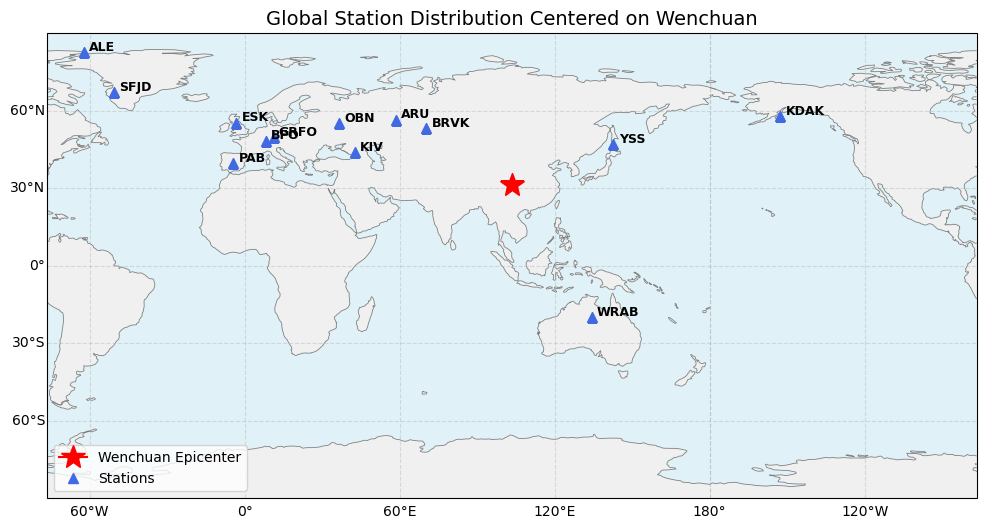

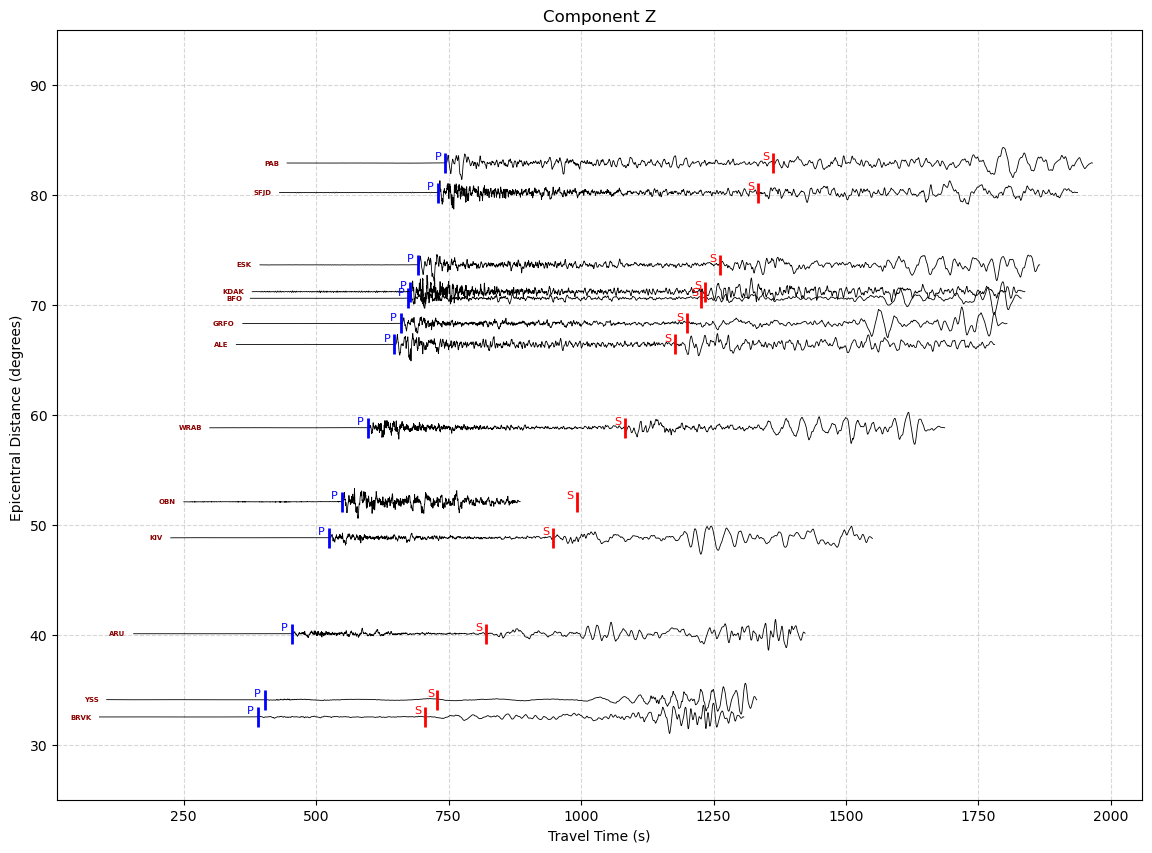

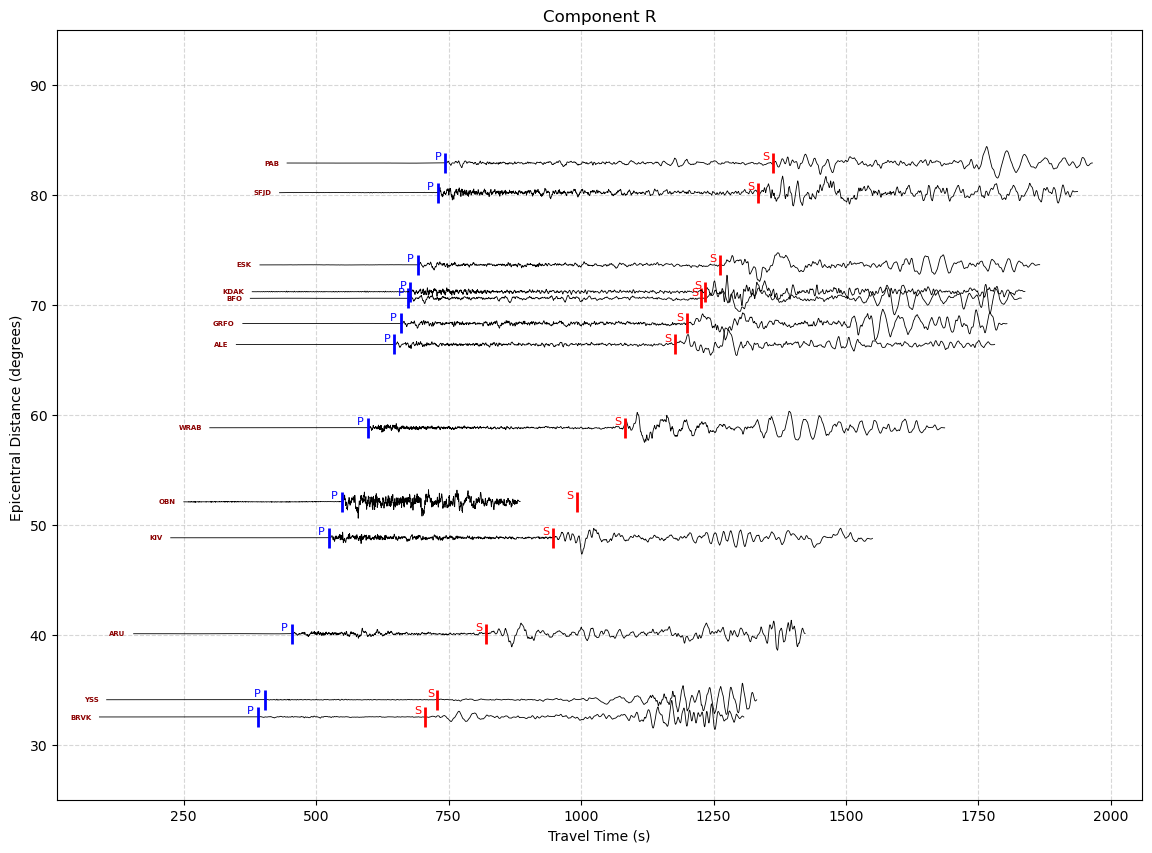

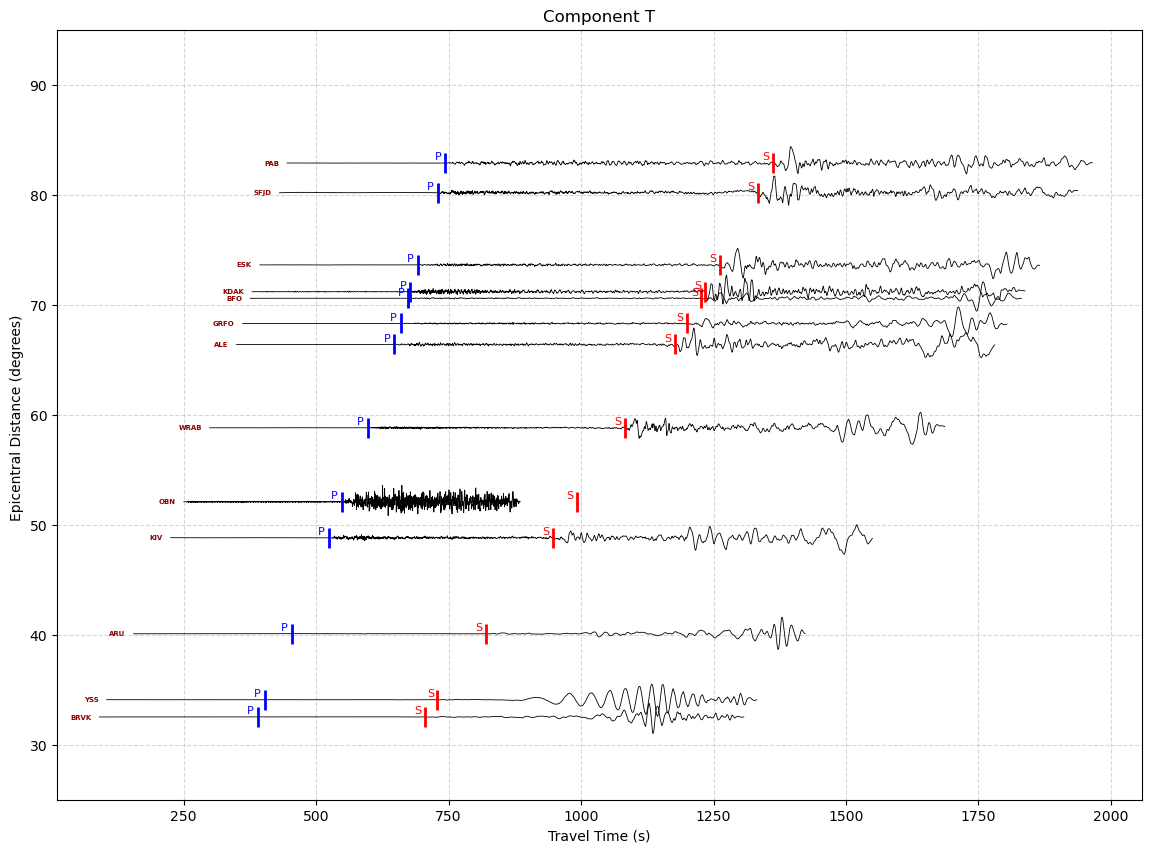

In [16]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from obspy import read, UTCDateTime
from obspy.taup import TauPyModel
from obspy.geodetics import kilometers2degrees

# ==========================================
# 0. 基本参数设置
# ==========================================
data_dir = "RESPONCE"
# 汶川大地震发震时刻和深度 (用于计算走时)
event_time = UTCDateTime("2008-05-12T06:28:01")
evla, evlo = 31.021, 103.367
evdp = 19.0  # 震源深度约 19 km

# 初始化 TauP 模型 (1D 走时计算 [cite: 8])
model = TauPyModel(model="iasp91")

# 读取所有处理好的 SAC 数据
st = read(os.path.join(data_dir, "*.sac"))

# 提取台站坐标、台站名和震中距用于画地图
sta_lats = []
sta_lons = []
sta_names = []  # 【新增】存储台站名称
for tr in st.select(component="Z"): # 仅用Z分量提取一次台站即可
    sta_lats.append(tr.stats.sac.stla)
    sta_lons.append(tr.stats.sac.stlo)
    sta_names.append(tr.stats.station) # 【新增】提取台站名

# --- 设定中心经度为汶川经度 ---
wenchuan_lon = 103.367
wenchuan_lat = 31.021

fig_map = plt.figure(figsize=(12, 8))

# 创建投影时指定 central_longitude
# 这会使地图的“横向中心”落在汶川
ax_map = plt.axes(projection=ccrs.PlateCarree(central_longitude=wenchuan_lon))

# 依然使用全局范围，但视觉中心已改变
ax_map.set_global() 

# 添加地理特征 
ax_map.add_feature(cfeature.LAND, facecolor='#f0f0f0')
ax_map.add_feature(cfeature.OCEAN, facecolor='#e0f2f7')
ax_map.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor='gray')

# 画震源 (红色五角星) [cite: 2]
ax_map.plot(wenchuan_lon, wenchuan_lat, marker='*', color='red', markersize=18, 
            transform=ccrs.PlateCarree(), label='Wenchuan Epicenter', zorder=5)

# 画台站 (蓝色三角形) [cite: 2]
ax_map.plot(sta_lons, sta_lats, marker='^', color='royalblue', markersize=7, 
            linestyle='', transform=ccrs.PlateCarree(), label='Stations', zorder=4)

# 【核心修改 1】：在地图上标注台站名称
for lon, lat, name in zip(sta_lons, sta_lats, sta_names):
    # lon + 2, lat + 2 是为了让文字偏离三角形一点点，避免重叠
    ax_map.text(lon + 2, lat + 2, name, transform=ccrs.PlateCarree(),
                fontsize=9, color='black', fontweight='bold', 
                ha='left', va='center', zorder=6)

# 添加经纬度网格
gl = ax_map.gridlines(draw_labels=True, linestyle='--', alpha=0.4)
gl.top_labels = False
gl.right_labels = False

plt.title("Global Station Distribution Centered on Wenchuan", fontsize=14)
plt.legend(loc='lower left')

plt.savefig("Figure_1_Wenchuan_Centered.png", dpi=1500, bbox_inches='tight')
print("✅ 第 1 张图：台站分布图已保存 (Figure_1_Wenchuan_Centered.png)")

# ==========================================
# 2. 绘制 Z, R, T 三分量地震图剖面 (第 2, 3, 4 张图) [cite: 2]
# ==========================================
components = ['Z', 'R', 'T']
# 振幅缩放因子，避免波形互相重叠 (可根据实际出图效果微调该数值)
scale_factor = 1.5 

for comp in components:
    fig, ax = plt.subplots(figsize=(14, 10)) # 稍微加宽画布以容纳台站名
    st_comp = st.select(component=comp)
    
    # 获取当前分量所有波形的最小相对时间，用于拓展X轴边界
    min_time_global = min([tr.times()[0] + (tr.stats.starttime - event_time) for tr in st_comp])
    
    for tr in st_comp:
        sta_name = tr.stats.station # 【新增】获取台站名
        
        # 获取距离 (将 km 转换为度 [cite: 2])
        dist_km = tr.stats.sac.dist
        dist_deg = kilometers2degrees(dist_km)
        
        # 计算每个数据点的相对走时 (X轴) [cite: 2]
        # X = 当前点的绝对时间 - 发震时刻
        times = tr.times() + (tr.stats.starttime - event_time)
        
        # 归一化振幅
        norm_data = tr.data / np.max(np.abs(tr.data))
        # 将波形平移到对应的震中距 (Y轴) [cite: 2]
        plot_data = norm_data * scale_factor + dist_deg
        
        # 画波形
        ax.plot(times, plot_data, color='black', linewidth=0.6)
        
        # 【核心修改 2】：在地震图剖面最左侧标注台站名称
        # 将文字放在 times[0] (波形起点) 左侧一点的位置
        ax.text(times[0] - 15, dist_deg, sta_name, 
                ha='right', va='center', fontsize=5, fontweight='bold', color='darkred')
        
        # 计算理论到时 [cite: 8]
        try:
            # P波 (P或Pdiff)
            arrivals_p = model.get_travel_times(source_depth_in_km=evdp, distance_in_degree=dist_deg, phase_list=["P", "Pdiff"])
            if arrivals_p:
                p_time = arrivals_p[0].time
                # 在地震波上标记理论到时 [cite: 2]
                ax.plot(p_time, dist_deg, marker='|', color='blue', markersize=15, markeredgewidth=2)
                ax.text(p_time - 20, dist_deg + 0.3, 'P', color='blue', fontsize=8)
                
            # S波 (S或Sdiff)
            arrivals_s = model.get_travel_times(source_depth_in_km=evdp, distance_in_degree=dist_deg, phase_list=["S", "Sdiff"])
            if arrivals_s:
                s_time = arrivals_s[0].time
                ax.plot(s_time, dist_deg, marker='|', color='red', markersize=15, markeredgewidth=2)
                ax.text(s_time - 20, dist_deg + 0.3, 'S', color='red', fontsize=8)
        except Exception as e:
            pass # 某些极端的震中距可能算不出基础震相，直接跳过

    ax.set_xlabel("Travel Time (s)")
    ax.set_ylabel("Epicentral Distance (degrees) ")
    ax.set_title(f"Component {comp}")
    ax.set_ylim(25, 95) # 作业要求30-90度，适当放宽显示范围 [cite: 2]
    
    # 【新增】将左侧X轴稍微向外扩展一点，留出写台站名字的空间
    ax.set_xlim(left=min_time_global - 80)
    
    ax.grid(True, linestyle='--', alpha=0.5)
    
    out_name = f"Figure_{components.index(comp)+2}_Profile_{comp}.png"
    plt.savefig(out_name, dpi=1500, bbox_inches='tight') # bbox_inches='tight' 确保坐标轴外的文字不被裁切
    print(f"✅ 第 {components.index(comp)+2} 张图：{comp} 分量剖面图已保存 ({out_name})")

plt.show()

✅ 第 1 张图：台站分布图已保存 (Figure_1_Wenchuan_Centered.pdf)
✅ 第 2 张图：Z 分量剖面图已保存 (Figure_2_Profile_Z.pdf)
✅ 第 3 张图：R 分量剖面图已保存 (Figure_3_Profile_R.pdf)
✅ 第 4 张图：T 分量剖面图已保存 (Figure_4_Profile_T.pdf)


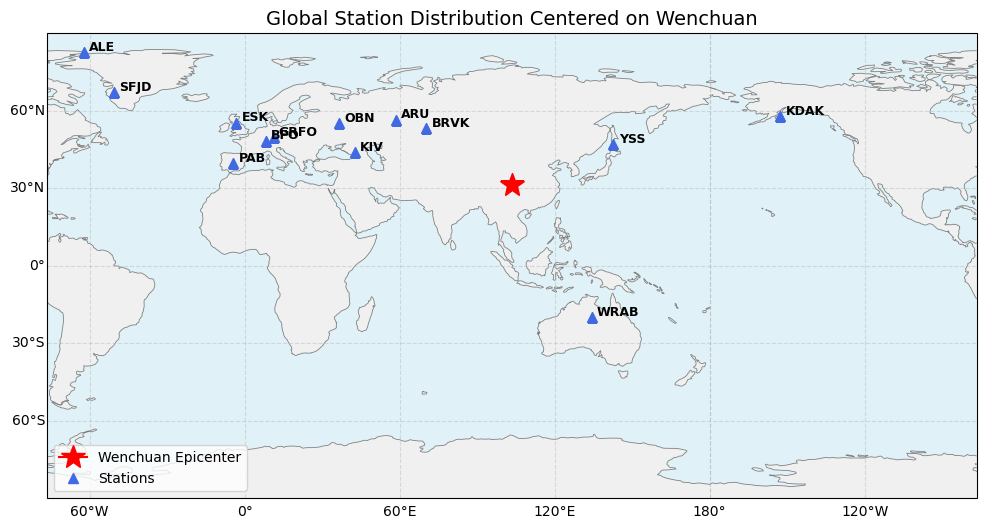

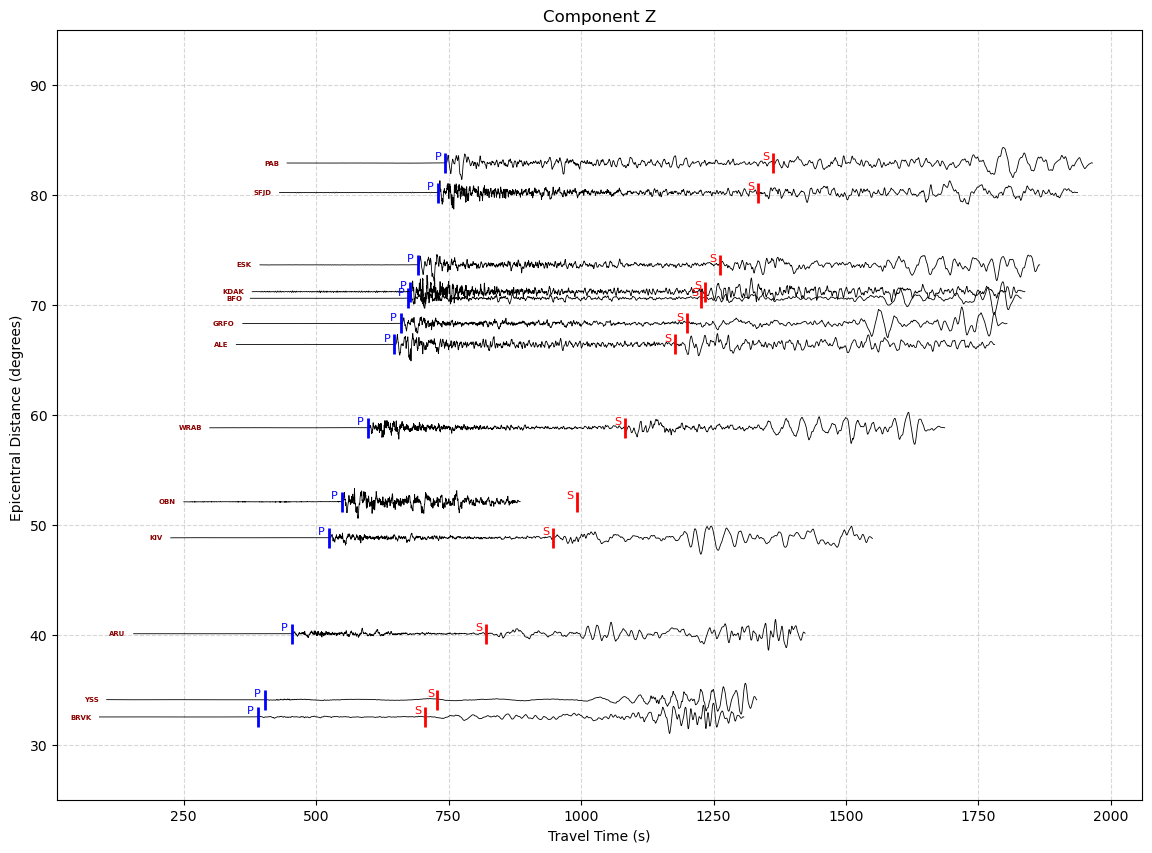

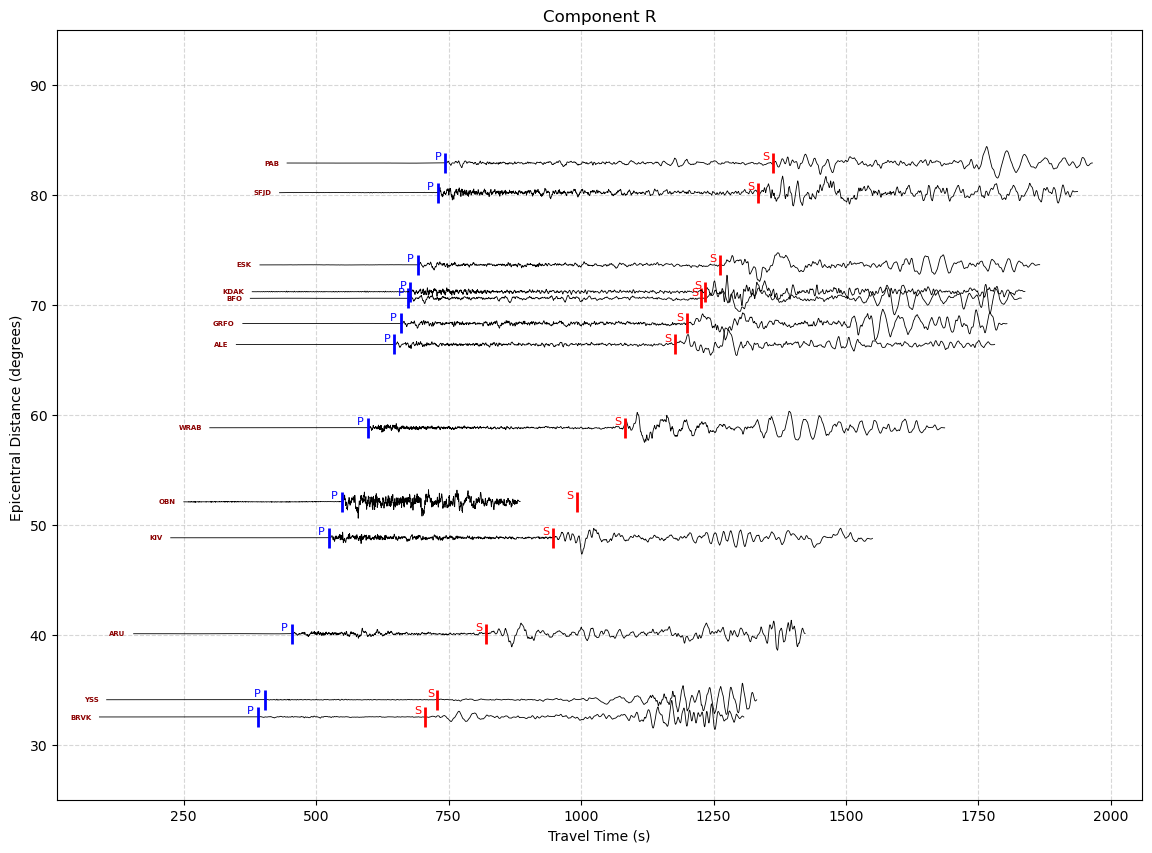

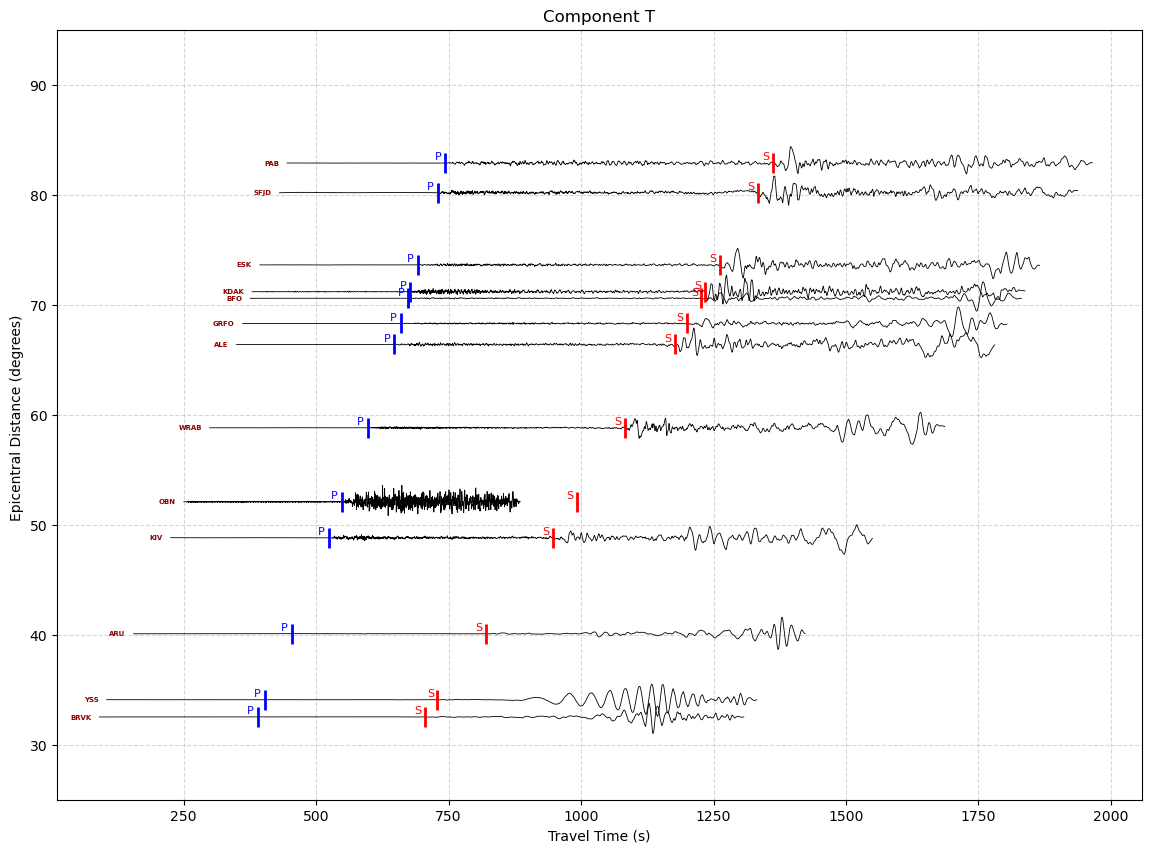

In [18]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from obspy import read, UTCDateTime
from obspy.taup import TauPyModel
from obspy.geodetics import kilometers2degrees

# ==========================================
# 0. 基本参数设置
# ==========================================
data_dir = "RESPONCE"
# 汶川大地震发震时刻和深度 (用于计算走时)
event_time = UTCDateTime("2008-05-12T06:28:01")
evla, evlo = 31.021, 103.367
evdp = 19.0  # 震源深度约 19 km

# 初始化 TauP 模型 (1D 走时计算)
model = TauPyModel(model="iasp91")

# 读取所有处理好的 SAC 数据
st = read(os.path.join(data_dir, "*.sac"))

# 提取台站坐标、台站名和震中距用于画地图
sta_lats = []
sta_lons = []
sta_names = []  
for tr in st.select(component="Z"): # 仅用Z分量提取一次台站即可
    sta_lats.append(tr.stats.sac.stla)
    sta_lons.append(tr.stats.sac.stlo)
    sta_names.append(tr.stats.station) 

# --- 设定中心经度为汶川经度 ---
wenchuan_lon = 103.367
wenchuan_lat = 31.021

fig_map = plt.figure(figsize=(12, 8))

# 创建投影时指定 central_longitude
# 这会使地图的“横向中心”落在汶川
ax_map = plt.axes(projection=ccrs.PlateCarree(central_longitude=wenchuan_lon))

# 依然使用全局范围，但视觉中心已改变
ax_map.set_global() 

# 添加地理特征 
ax_map.add_feature(cfeature.LAND, facecolor='#f0f0f0')
ax_map.add_feature(cfeature.OCEAN, facecolor='#e0f2f7')
ax_map.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor='gray')

# 画震源 (红色五角星)
ax_map.plot(wenchuan_lon, wenchuan_lat, marker='*', color='red', markersize=18, 
            transform=ccrs.PlateCarree(), label='Wenchuan Epicenter', zorder=5)

# 画台站 (蓝色三角形)
ax_map.plot(sta_lons, sta_lats, marker='^', color='royalblue', markersize=7, 
            linestyle='', transform=ccrs.PlateCarree(), label='Stations', zorder=4)

# 在地图上标注台站名称
for lon, lat, name in zip(sta_lons, sta_lats, sta_names):
    # lon + 2, lat + 2 是为了让文字偏离三角形一点点，避免重叠
    ax_map.text(lon + 2, lat + 2, name, transform=ccrs.PlateCarree(),
                fontsize=9, color='black', fontweight='bold', 
                ha='left', va='center', zorder=6)

# 添加经纬度网格
gl = ax_map.gridlines(draw_labels=True, linestyle='--', alpha=0.4)
gl.top_labels = False
gl.right_labels = False

plt.title("Global Station Distribution Centered on Wenchuan", fontsize=14)
plt.legend(loc='lower left')

# 【修改为 PDF 输出】
plt.savefig("Figure_1_Wenchuan_Centered.pdf", format='pdf', bbox_inches='tight')
print("✅ 第 1 张图：台站分布图已保存 (Figure_1_Wenchuan_Centered.pdf)")

# ==========================================
# 2. 绘制 Z, R, T 三分量地震图剖面 (第 2, 3, 4 张图)
# ==========================================
components = ['Z', 'R', 'T']
# 振幅缩放因子，避免波形互相重叠 (可根据实际出图效果微调该数值)
scale_factor = 1.5 

for comp in components:
    fig, ax = plt.subplots(figsize=(14, 10)) # 稍微加宽画布以容纳台站名
    st_comp = st.select(component=comp)
    
    # 获取当前分量所有波形的最小相对时间，用于拓展X轴边界
    min_time_global = min([tr.times()[0] + (tr.stats.starttime - event_time) for tr in st_comp])
    
    for tr in st_comp:
        sta_name = tr.stats.station 
        
        # 获取距离 (将 km 转换为度)
        dist_km = tr.stats.sac.dist
        dist_deg = kilometers2degrees(dist_km)
        
        # 计算每个数据点的相对走时 (X轴)
        # X = 当前点的绝对时间 - 发震时刻
        times = tr.times() + (tr.stats.starttime - event_time)
        
        # 归一化振幅
        norm_data = tr.data / np.max(np.abs(tr.data))
        # 将波形平移到对应的震中距 (Y轴)
        plot_data = norm_data * scale_factor + dist_deg
        
        # 画波形
        ax.plot(times, plot_data, color='black', linewidth=0.6)
        
        # 在地震图剖面最左侧标注台站名称
        ax.text(times[0] - 15, dist_deg, sta_name, 
                ha='right', va='center', fontsize=5, fontweight='bold', color='darkred')
        
        # 计算理论到时
        try:
            # P波 (P或Pdiff)
            arrivals_p = model.get_travel_times(source_depth_in_km=evdp, distance_in_degree=dist_deg, phase_list=["P", "Pdiff"])
            if arrivals_p:
                p_time = arrivals_p[0].time
                # 在地震波上标记理论到时
                ax.plot(p_time, dist_deg, marker='|', color='blue', markersize=15, markeredgewidth=2)
                ax.text(p_time - 20, dist_deg + 0.3, 'P', color='blue', fontsize=8)
                
            # S波 (S或Sdiff)
            arrivals_s = model.get_travel_times(source_depth_in_km=evdp, distance_in_degree=dist_deg, phase_list=["S", "Sdiff"])
            if arrivals_s:
                s_time = arrivals_s[0].time
                ax.plot(s_time, dist_deg, marker='|', color='red', markersize=15, markeredgewidth=2)
                ax.text(s_time - 20, dist_deg + 0.3, 'S', color='red', fontsize=8)
        except Exception as e:
            pass # 某些极端的震中距可能算不出基础震相，直接跳过

    ax.set_xlabel("Travel Time (s)")
    ax.set_ylabel("Epicentral Distance (degrees) ")
    ax.set_title(f"Component {comp}")
    ax.set_ylim(25, 95) # 作业要求30-90度，适当放宽显示范围
    
    # 将左侧X轴稍微向外扩展一点，留出写台站名字的空间
    ax.set_xlim(left=min_time_global - 80)
    
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # 【修改为 PDF 输出】
    out_name = f"Figure_{components.index(comp)+2}_Profile_{comp}.pdf"
    plt.savefig(out_name, format='pdf', bbox_inches='tight') 
    print(f"✅ 第 {components.index(comp)+2} 张图：{comp} 分量剖面图已保存 ({out_name})")

plt.show()